In [ ]:
!pip install optuna
!pip install lightgbm
!pip install catboost

In [ ]:
import pandas as pd
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
%matplotlib inline
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_validate
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
import optuna
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import accuracy_score
from sklearn.ensemble import VotingClassifier
from lightgbm import LGBMClassifier, plot_importance
from catboost import CatBoostClassifier

In [ ]:
pd.options.display.max_rows=100
pd.options.display.max_columns=None

In [ ]:
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=2024)

In [ ]:
data = pd.read_csv('test.csv')
train_data, test_data = train_test_split(data, test_size=0.2, random_state=2024)

In [ ]:
TARGET_FEATURES = ['Pastry', 'Z_Scratch', 'K_Scatch', 'Stains','Dirtiness', 'Bumps', 'Other_Faults']

In [ ]:
train_data.drop(['id'],axis = 1,inplace = True)
test_data.drop(['id'],inplace = True,axis = 1)

In [ ]:
targets_bin = train_data[TARGET_FEATURES]
y_xgb = targets_bin

In [ ]:
y_xgb.shape

(1552, 7)

In [ ]:
train_data['Target'] = np.argmax(train_data[TARGET_FEATURES].values, axis=1) + 1
train_data.loc[train_data[TARGET_FEATURES].sum(axis=1) == 0, 'Target'] = 0

In [ ]:
train_data.drop(TARGET_FEATURES, inplace=True,axis =1)

In [ ]:
def feature_engineering(data):
    data['Ratio_Length_Thickness'] = data['Length_of_Conveyer'] / data['Steel_Plate_Thickness']
    data['Normalized_Steel_Thickness'] = (data['Steel_Plate_Thickness'] - data['Steel_Plate_Thickness'].min()) / (data['Steel_Plate_Thickness'].max() - data['Steel_Plate_Thickness'].min())
    data['X_Range*Pixels_Areas'] = (data['X_Maximum'] - data['X_Minimum']) * data['Pixels_Areas']
    return data

In [ ]:
train_data = feature_engineering(train_data)
test_data = feature_engineering(test_data)

In [ ]:
features_to_drop = ['Y_Minimum', 'Steel_Plate_Thickness', 'Sum_of_Luminosity', 'Edges_X_Index', 'SigmoidOfAreas', 'Luminosity_Index', 'TypeOfSteel_A300']

In [ ]:
train_data = train_data.drop(features_to_drop,axis = 1)
test_data = test_data.drop(features_to_drop,axis = 1)

In [ ]:
X = train_data.drop(['Target'], axis=1)
y = train_data['Target']

In [ ]:
X

,X_Minimum,X_Maximum,Y_Maximum,Pixels_Areas,X_Perimeter,Y_Perimeter,Minimum_of_Luminosity,Maximum_of_Luminosity,Length_of_Conveyer,TypeOfSteel_A400,Edges_Index,Empty_Index,Square_Index,Outside_X_Index,Edges_Y_Index,Outside_Global_Index,LogOfAreas,Log_X_Index,Log_Y_Index,Orientation_Index,Ratio_Length_Thickness,Normalized_Steel_Thickness,X_Range*Pixels_Areas
1548,127,136,503796,68,13,13,102,134,1354,1,0.1876,0.4188,0.6923,0.0066,1.0000,1.0,1.8325,0.9542,1.1139,0.3077,33.850000,0.000000,612
513,39,191,2400148,8457,636,383,38,141,1400,1,0.0557,0.6434,0.9744,0.1086,0.4073,1.0,3.9272,2.1818,2.1931,0.0256,35.000000,0.000000,1285464
460,41,196,1494716,12729,634,404,29,143,1400,1,0.0586,0.5488,0.8516,0.1107,0.4505,1.0,4.1048,2.1903,2.2601,0.1484,35.000000,0.000000,1972995
740,1145,1152,1083344,22,7,4,116,148,1358,1,0.3034,0.2143,0.5714,0.0052,1.0000,0.0,1.3424,0.8451,0.6021,-0.4286,27.160000,0.038462,154
154,14,23,1461302,265,47,56,106,156,1358,0,0.0206,0.4647,0.1636,0.0066,0.9821,1.0,2.4232,0.9542,1.7404,0.8364,19.400000,0.115385,2385
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
539,103,161,157529,2463,262,168,116,140,1360,1,0.1515,0.6140,0.5273,0.0426,0.6548,1.0,3.3915,1.7634,2.0414,0.4727,34.000000,0.000000,142854
640,41,212,1970846,6603,271,138,38,127,1358,1,0.0604,0.4237,0.3918,0.1259,0.4855,0.0,3.8197,2.2330,1.8261,-0.6082,33.950000,0.000000,1129113
608,41,214,1576955,6353,260,120,37,125,1358,1,0.0604,0.4350,0.3757,0.1274,0.5417,0.0,3.8030,2.2380,1.8129,-0.6243,33.950000,0.000000,1099069
1530,39,46,1135377,52,13,13,87,126,1688,0,0.0462,0.4286,0.5385,0.0041,1.0000,1.0,1.7160,0.8451,1.1139,0.4615,28.133333,0.076923,364


[I 2024-08-17 08:25:31,299] A new study created in memory with name: xgb_model_training
[I 2024-08-17 08:25:42,861] Trial 0 finished with value: 0.9530789566076325 and parameters: {'grow_policy': 'depthwise', 'multi_strategy': 'one_output_per_tree', 'learning_rate': 0.058944382812752, 'gamma': 0.0025161152688292854, 'subsample': 0.37462438159079137, 'colsample_bytree': 0.822748072155951, 'max_depth': 5, 'min_child_weight': 3, 'lambda': 0.14458762965871008, 'alpha': 0.45765516464156203}. Best is trial 0 with value: 0.9530789566076325.
[I 2024-08-17 08:27:22,670] Trial 1 finished with value: 0.9578527850999745 and parameters: {'grow_policy': 'depthwise', 'multi_strategy': 'one_output_per_tree', 'learning_rate': 0.005987506596153857, 'gamma': 6.318368447455647e-05, 'subsample': 0.7115958645501033, 'colsample_bytree': 0.5530209936247484, 'max_depth': 10, 'min_child_weight': 3, 'lambda': 9.148678336072763, 'alpha': 0.10000710761954545}. Best is trial 1 with value: 0.9578527850999745.
[I 202

Best trial average AUC: 0.9653
Best hyperparameters:
grow_policy: lossguide
multi_strategy: one_output_per_tree
learning_rate: 0.01135946628246749
gamma: 0.131734493258287
subsample: 0.8827823794210427
colsample_bytree: 0.6416970269613537
max_depth: 9
min_child_weight: 1
lambda: 0.10982549617020822
alpha: 0.028640678169538036


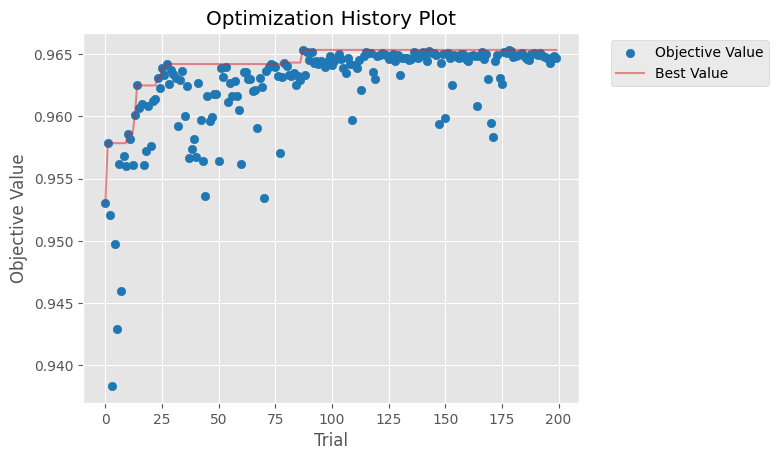

<ipython-input-29-5944788b317e>:74: ExperimentalWarning: plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  fig = optuna_vis.plot_param_importances(study)


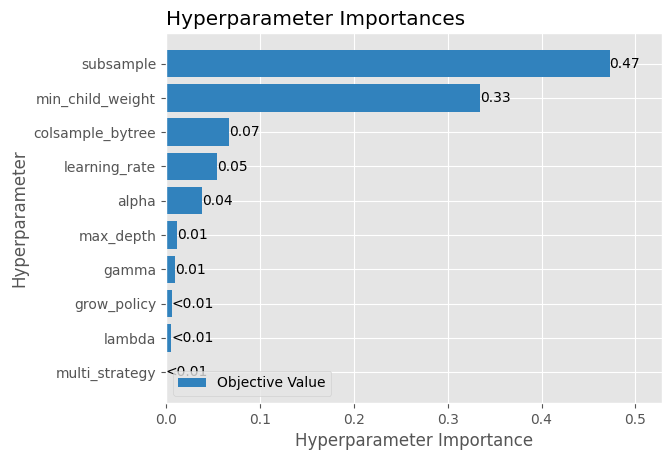

In [ ]:
import optuna
import numpy as np
import pandas as pd
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold
import matplotlib.pyplot as plt
import optuna.visualization.matplotlib as optuna_vis

# Assuming X, y, y_xgb, and targets_bin are already defined

RETRAIN_XGB_MODEL = True  # Set to True to perform optimization

def objective(trial):
    # Define hyperparameters to tune
    param = {
        'grow_policy': trial.suggest_categorical('grow_policy', ["depthwise", "lossguide"]),
        'multi_strategy': trial.suggest_categorical('multi_strategy', ["one_output_per_tree"]),
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.1),
        'gamma': trial.suggest_float('gamma', 1e-5, 0.5, log=True),
        'subsample': trial.suggest_float('subsample', 0.3, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.3, 1.0),
        'max_depth': trial.suggest_int('max_depth', 3, 15),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 7),
        'lambda': trial.suggest_float('lambda', 1e-3, 10.0, log=True),
        'alpha': trial.suggest_float('alpha', 1e-3, 10.0, log=True),
    }
    param['n_estimators'] = 3000
    param['early_stopping_rounds'] = 50
    param['booster'] = 'gbtree'
    param["verbosity"] = 0
    param['tree_method'] = "hist"

    auc_scores = []
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)  # 5-fold cross-validation

    for train_idx, valid_idx in cv.split(X, y):
        X_train_fold, X_valid_fold = X.iloc[train_idx], X.iloc[valid_idx]
        y_train_fold, y_valid_fold = y.iloc[train_idx], y.iloc[valid_idx]
        y_xgb_train_fold, y_xgb_valid_fold = y_xgb.iloc[train_idx], y_xgb.iloc[valid_idx]

        # Create and fit the model
        model = XGBClassifier(**param)
        model.fit(X_train_fold, y_xgb_train_fold, eval_set=[(X_valid_fold, y_xgb_valid_fold)], verbose=False)

        # Predict class probabilities
        y_prob = model.predict_proba(X_valid_fold)

        # Compute the AUC for each class and take the average
        average_auc = roc_auc_score(targets_bin.iloc[valid_idx], y_prob, multi_class="ovr", average="macro")
        auc_scores.append(average_auc)

    # Return the average AUC score across all folds
    return np.mean(auc_scores)

if RETRAIN_XGB_MODEL:
    study = optuna.create_study(direction='maximize', study_name="xgb_model_training")
    study.optimize(objective, n_trials=200)  # Adjust the number of trials as necessary

    # Output the optimization results
    print(f"Best trial average AUC: {study.best_value:.4f}")
    print("Best hyperparameters:")
    for key, value in study.best_params.items():
        print(f"{key}: {value}")

    # Ensure interactive mode is on for plotting
    plt.ion()

    # Plot optimization history
    fig = optuna_vis.plot_optimization_history(study)
    plt.show()

    # Plot parameter importance
    fig = optuna_vis.plot_param_importances(study)
    plt.show()

